In [2]:
from pathlib import Path
import json
import pandas as pd
from src.config import config

try:
    from src.data_management.builders import VolatilityBuilder
    dataset_path = VolatilityBuilder.get_output_filename()
except Exception as exc:
    config = json.loads(Path("resources/data_config.json").read_text(encoding="utf-8"))
    dataset_path = Path("data") / "volatility_data" / f"{config['volatility_step']['output_filename']}.csv"
    print(f"Falling back to direct path resolution because importing VolatilityBuilder failed: {exc}")

df = pd.read_csv(dataset_path, sep=";", low_memory=False, dtype="str")
df.head()

,OptionContractCode,FutureContractCode,UnderlyingPrice,SessionDate,MarketCode,TradeExecID,TradePriceOption,Quantity,TradeType,StrikePrice,MaturityDatetime,ExecTime,ExecDatetime,TimeToExpiration,UnderlyingExecDatetime,Rate,t_in_years,r_in_decimals,option_type,ImpliedVolatility
0,CIBX 9600F17,FIBXF7,9305.0,2017-01-02,M3,OM0001645363,45.0,3,M,9600.0,2017-01-20 21:00:00,1900-01-01 09:13:43,2017-01-02 09:13:43,18.49047453703704,2017-01-02 09:13:17,-0.39721397493384986,0.05065883434804669,-0.003972139749338499,c,0.17442506323580703
1,PIBX 8200F17,FIBXF7,9314.0,2017-01-02,M3,OM0001645364,3.0,5000,H,8200.0,2017-01-20 21:00:00,1900-01-01 09:23:09,2017-01-02 09:23:09,18.483923611111116,2017-01-02 09:23:03,-0.3973547523673256,0.05064088660578388,-0.003973547523673256,p,0.2643840065724571
2,CIBX 9300F17,FIBXF7,9314.0,2017-01-02,M3,OM0001645366,165.0,1,M,9300.0,2017-01-20 21:00:00,1900-01-01 09:24:08,2017-01-02 09:24:08,18.48324074074074,2017-01-02 09:23:19,-0.3973694327900245,0.050639015728056826,-0.003973694327900245,c,0.18895767213266945
3,PIBX 8500F17,FIBXF7,9322.0,2017-01-02,M3,OM0001645368,9.0,5000,H,8500.0,2017-01-20 21:00:00,1900-01-01 09:29:21,2017-01-02 09:29:21,18.479618055555555,2017-01-02 09:29:01,-0.397447331821968,0.050629090563165904,-0.00397447331821968,p,0.2421774300535976
4,CIBX 9400F17,FIBXF7,9331.0,2017-01-02,M3,OM0001645370,123.0,1,M,9400.0,2017-01-20 21:00:00,1900-01-01 09:32:52,2017-01-02 09:32:52,18.477175925925927,2017-01-02 09:32:52,-0.3974998624635092,0.050622399797057335,-0.003974998624635092,c,0.18444153064803748


In [ ]:
import pandas as pd
from src.data_management.loaders import VolatilityStepLoader
from src.enums.data_enums import VolatilityDBEnum

df = VolatilityStepLoader.load()

df["MaturityDatetime"] = pd.to_datetime(df["MaturityDatetime"], format="mixed")
df["ExecDatetime"] = pd.to_datetime(df["ExecDatetime"], format="mixed")
df["UnderlyingExecDatetime"] = pd.to_datetime(
    df["UnderlyingExecDatetime"], format="mixed"
)

# Explainability Analysis of a Neural Network for Implied Volatility

This notebook expands the project dataset into a full quantitative workflow focused on predicting `ImpliedVolatility` and explaining the resulting model.

The workflow is organized as follows:

1. Load and inspect the dataset generated by the project pipeline.
2. Infer the modelling features directly from the CSV schema.
3. Prepare train, validation, and test sets.
4. Train a feed-forward neural network for tabular regression.
5. Analyse the fitted model with SHAP-style Shapley values.
6. Study the local sensitivity of predicted implied volatility.
7. Price options with Black-Scholes using the predicted volatility.
8. Visualize option-price sensitivities.
9. Compare observed market prices with model-implied Black-Scholes prices when possible.
10. Summarize the key findings and limitations.

Two implementation constraints are worth stating explicitly:

- The current notebook kernel does not expose TensorFlow or PyTorch, so the regression model is implemented with `sklearn.neural_network.MLPRegressor`, which is still a fully connected neural network trained with mini-batch Adam.
- The dedicated `shap` package is not available in the kernel, so SHAP is approximated with Monte Carlo Shapley values computed directly from the fitted model. This keeps the explainability section executable with the installed scientific Python stack.

In [ ]:
import copy
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import norm
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", message="Stochastic Optimizer: Maximum iterations")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = True

RANDOM_STATE = 42
TRAINING_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5
EXPLAINABILITY_SAMPLE_SIZE = 50
BACKGROUND_SAMPLE_SIZE = 40
SHAP_PERMUTATIONS = 20
MAX_CATEGORICAL_CARDINALITY = 25
MODELING_SAMPLE_SIZE = 120000

rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))



def compute_regression_metrics(y_true, y_pred) -> dict[str, float]:
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }

def normalize_option_type(value) -> str:
    value_str = str(value).strip().lower()
    if value_str in {"p", "put", "-1"}:
        return "put"
    return "call"

## 1. Data Loading

The dataset is loaded directly from the project builder output. The first inspection reports the dataset shape, column names, data types, missing values, a preview of the rows, and broad summary statistics.

In [8]:
df.head()

,OptionContractCode,FutureContractCode,UnderlyingPrice,SessionDate,MarketCode,TradeExecID,TradePriceOption,Quantity,TradeType,StrikePrice,MaturityDatetime,ExecTime,ExecDatetime,TimeToExpiration,UnderlyingExecDatetime,Rate,t_in_years,r_in_decimals,option_type,ImpliedVolatility
0,CIBX 9600F17,FIBXF7,9305.0,2017-01-02,M3,OM0001645363,45.0,3,M,9600.0,2017-01-20 21:00:00,1900-01-01 09:13:43,2017-01-02 09:13:43,18.49047453703704,2017-01-02 09:13:17,-0.39721397493384986,0.05065883434804669,-0.003972139749338499,c,0.17442506323580703
1,PIBX 8200F17,FIBXF7,9314.0,2017-01-02,M3,OM0001645364,3.0,5000,H,8200.0,2017-01-20 21:00:00,1900-01-01 09:23:09,2017-01-02 09:23:09,18.483923611111116,2017-01-02 09:23:03,-0.3973547523673256,0.05064088660578388,-0.003973547523673256,p,0.2643840065724571
2,CIBX 9300F17,FIBXF7,9314.0,2017-01-02,M3,OM0001645366,165.0,1,M,9300.0,2017-01-20 21:00:00,1900-01-01 09:24:08,2017-01-02 09:24:08,18.48324074074074,2017-01-02 09:23:19,-0.3973694327900245,0.050639015728056826,-0.003973694327900245,c,0.18895767213266945
3,PIBX 8500F17,FIBXF7,9322.0,2017-01-02,M3,OM0001645368,9.0,5000,H,8500.0,2017-01-20 21:00:00,1900-01-01 09:29:21,2017-01-02 09:29:21,18.479618055555555,2017-01-02 09:29:01,-0.397447331821968,0.050629090563165904,-0.00397447331821968,p,0.2421774300535976
4,CIBX 9400F17,FIBXF7,9331.0,2017-01-02,M3,OM0001645370,123.0,1,M,9400.0,2017-01-20 21:00:00,1900-01-01 09:32:52,2017-01-02 09:32:52,18.477175925925927,2017-01-02 09:32:52,-0.3974998624635092,0.050622399797057335,-0.003974998624635092,c,0.18444153064803748


Dataset shape: (406690, 20)


,column_name
0,OptionContractCode
1,FutureContractCode
2,UnderlyingPrice
3,SessionDate
4,MarketCode
5,TradeExecID
6,TradePriceOption
7,Quantity
8,TradeType
9,StrikePrice


,missing_values
OptionContractCode,0
FutureContractCode,0
UnderlyingPrice,0
SessionDate,0
MarketCode,0
TradeExecID,0
TradePriceOption,0
Quantity,0
TradeType,0
StrikePrice,0


,OptionContractCode,FutureContractCode,UnderlyingPrice,SessionDate,MarketCode,TradeExecID,TradePriceOption,Quantity,TradeType,StrikePrice,MaturityDatetime,ExecTime,ExecDatetime,TimeToExpiration,UnderlyingExecDatetime,Rate,t_in_years,r_in_decimals,option_type,ImpliedVolatility
0,CIBX 9600F17,FIBXF7,9305.0,2017-01-02,M3,OM0001645363,45.0,3,M,9600.0,2017-01-20 21:00:00,1900-01-01 09:13:43,2017-01-02 09:13:43,18.490475,2017-01-02 09:13:17,-0.397214,0.05065883434804669,-0.003972139749338499,c,0.174425
1,PIBX 8200F17,FIBXF7,9314.0,2017-01-02,M3,OM0001645364,3.0,5000,H,8200.0,2017-01-20 21:00:00,1900-01-01 09:23:09,2017-01-02 09:23:09,18.483923,2017-01-02 09:23:03,-0.397355,0.05064088660578388,-0.003973547523673256,p,0.264384
2,CIBX 9300F17,FIBXF7,9314.0,2017-01-02,M3,OM0001645366,165.0,1,M,9300.0,2017-01-20 21:00:00,1900-01-01 09:24:08,2017-01-02 09:24:08,18.48324,2017-01-02 09:23:19,-0.397369,0.050639015728056826,-0.003973694327900245,c,0.188958
3,PIBX 8500F17,FIBXF7,9322.0,2017-01-02,M3,OM0001645368,9.0,5000,H,8500.0,2017-01-20 21:00:00,1900-01-01 09:29:21,2017-01-02 09:29:21,18.479618,2017-01-02 09:29:01,-0.397447,0.050629090563165904,-0.00397447331821968,p,0.242177
4,CIBX 9400F17,FIBXF7,9331.0,2017-01-02,M3,OM0001645370,123.0,1,M,9400.0,2017-01-20 21:00:00,1900-01-01 09:32:52,2017-01-02 09:32:52,18.477177,2017-01-02 09:32:52,-0.3975,0.050622399797057335,-0.003974998624635092,c,0.184442


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
OptionContractCode,406690,4283,PIBX10000Z17,1035,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FutureContractCode,406690,72,FIBXZ8,19003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnderlyingPrice,406690.0,<NA>,<NA>,<NA>,9162.141602,5777.0,8700.0,9230.0,9820.0,11179.0,980.253662
SessionDate,406690,1402,2017-05-18,1108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MarketCode,406690,1,M3,406690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TradeExecID,406690,406690,OM0001645363,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TradePriceOption,406690.0,<NA>,<NA>,<NA>,150.06781,0.01,35.0,83.0,176.0,6078.009766,236.528717
Quantity,406690.0,<NA>,<NA>,<NA>,30.055652,1.0,1.0,1.0,3.0,40000.0,444.073885
TradeType,406690,6,M,402832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StrikePrice,406690.0,<NA>,<NA>,<NA>,9083.357422,3500.0,8500.0,9200.0,9800.0,16000.0,1070.399658


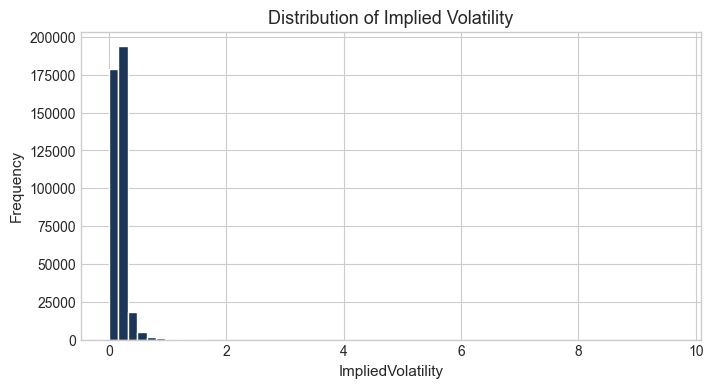


The dataset contains **406,690 rows** and **20 columns**.

The target `ImpliedVolatility` is missing in **6,663 rows**, so those rows will be removed before model fitting.

Even before feature selection, three modelling issues are visible:

- several columns are clear contract or trade identifiers (`TradeExecID`, contract codes);
- `TradePriceOption` is a leakage candidate because implied volatility is usually backed out from an observed option premium;
- raw dates and timestamps should be transformed into lower-dimensional calendar features before modelling.


In [5]:
print(f"Dataset shape: {df.shape}")

display(pd.DataFrame({"column_name": df.columns}))
display(df.isna().sum().rename("missing_values").to_frame())
display(df.head())
display(df.describe(include="all").transpose())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df[TARGET_COLUMN].dropna(), bins=60, color="#1d3557", edgecolor="white")
ax.set_title("Distribution of Implied Volatility")
ax.set_xlabel(TARGET_COLUMN)
ax.set_ylabel("Frequency")
plt.show()

data_loading_summary = f'''
The dataset contains **{df.shape[0]:,} rows** and **{df.shape[1]} columns**.

The target `{TARGET_COLUMN}` is missing in **{df[TARGET_COLUMN].isna().sum():,} rows**, so those rows will be removed before model fitting.

Even before feature selection, three modelling issues are visible:

- several columns are clear contract or trade identifiers (`TradeExecID`, contract codes);
- `TradePriceOption` is a leakage candidate because implied volatility is usually backed out from an observed option premium;
- raw dates and timestamps should be transformed into lower-dimensional calendar features before modelling.
'''
display(Markdown(data_loading_summary))

## 3. Data Preparation

The cleaned dataset is split into train, validation, and test sets. Numeric variables are median-imputed and standardized; categorical variables are mode-imputed and one-hot encoded. The final feature names after preprocessing are kept for later inspection.

In [21]:
clean_df = df.dropna(subset=[TARGET_COLUMN]).copy()

In [22]:
df.columns

Index(['OptionContractCode', 'FutureContractCode', 'UnderlyingPrice',
       'SessionDate', 'MarketCode', 'TradeExecID', 'TradePriceOption',
       'Quantity', 'TradeType', 'StrikePrice', 'MaturityDatetime', 'ExecTime',
       'ExecDatetime', 'TimeToExpiration', 'UnderlyingExecDatetime', 'Rate',
       't_in_years', 'r_in_decimals', 'option_type', 'ImpliedVolatility'],
      dtype='str')

In [58]:
FEATURE_COLUMNS = [
    "UnderlyingPrice",
    "TradePriceOption",
    "TradeType",
    "StrikePrice",
    "TimeToExpiration",
    "Rate",
    "option_type",
]
TARGET_COLUMN = "ImpliedVolatility"

X = clean_df[FEATURE_COLUMNS]
y = clean_df[TARGET_COLUMN].to_numpy(dtype=float)

In [59]:
from sklearn.preprocessing import OrdinalEncoder

def make_ordinal_encoder() -> OrdinalEncoder:
    try:
        return OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1,
        )
    except TypeError:
        return OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

In [60]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE,
)
X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.17647058823529413,
    random_state=RANDOM_STATE,
)

train_reference_df = clean_df.loc[X_train_raw.index].copy()
valid_reference_df = clean_df.loc[X_valid_raw.index].copy()
test_reference_df = clean_df.loc[X_test_raw.index].copy()

numeric_feature_columns = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_feature_columns = [
    column for column in X_train_raw.columns if column not in numeric_feature_columns
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_feature_columns,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("ordinal", make_ordinal_encoder()),
                ]
            ),
            categorical_feature_columns,
        ),
    ],
    remainder="drop",
)

X_train_processed = preprocessor.fit_transform(X_train_raw)
X_valid_processed = preprocessor.transform(X_valid_raw)
X_test_processed = preprocessor.transform(X_test_raw)


split_summary_df = pd.DataFrame(
    {
        "subset": ["Train", "Validation", "Test"],
        "n_rows": [len(X_train_raw), len(X_valid_raw), len(X_test_raw)],
        "share_of_clean_sample": [
            len(X_train_raw) / len(X),
            len(X_valid_raw) / len(X),
            len(X_test_raw) / len(X),
        ],
    }
)
display(split_summary_df)

print(f"Processed training matrix shape: {X_train_processed.shape}")
print(f"Processed validation matrix shape: {X_valid_processed.shape}")
print(f"Processed test matrix shape: {X_test_processed.shape}")

preprocessing_summary = f'''
The preprocessing pipeline yields **{X_train_processed.shape[1]} model inputs** after scaling numeric variables
and compact ordinal encoding of the remaining low-cardinality categorical variables.

This avoids the memory blow-up that can occur with dense one-hot encoding while keeping the feature space interpretable for the explainability section.
'''
display(Markdown(preprocessing_summary))

,subset,n_rows,share_of_clean_sample
0,Train,280018,0.699998
1,Validation,60004,0.150000
2,Test,60005,0.150002


Processed training matrix shape: (280018, 7)
Processed validation matrix shape: (60004, 7)
Processed test matrix shape: (60005, 7)



The preprocessing pipeline yields **7 model inputs** after scaling numeric variables
and compact ordinal encoding of the remaining low-cardinality categorical variables.

This avoids the memory blow-up that can occur with dense one-hot encoding while keeping the feature space interpretable for the explainability section.


## 4. Deep Learning Model

A feed-forward neural network is trained for tabular regression. The architecture uses three hidden layers and mini-batch Adam optimization. Validation performance is tracked epoch by epoch, and the best validation model is retained through manual early stopping.

In [61]:
neural_network = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    batch_size=2048,
    learning_rate_init=1e-3,
    alpha=1e-4,
    max_iter=1,
    warm_start=True,
    shuffle=True,
    random_state=RANDOM_STATE,
    early_stopping=False,
)

training_history = []
best_validation_rmse = np.inf
best_model = None
patience_counter = 0

for epoch in range(1, TRAINING_EPOCHS + 1):
    neural_network.fit(X_train_processed, y_train)

    train_epoch_predictions = neural_network.predict(X_train_processed)
    valid_epoch_predictions = neural_network.predict(X_valid_processed)

    train_epoch_rmse = rmse(y_train, train_epoch_predictions)
    valid_epoch_rmse = rmse(y_valid, valid_epoch_predictions)

    training_history.append(
        {
            "epoch": epoch,
            "train_rmse": train_epoch_rmse,
            "validation_rmse": valid_epoch_rmse,
        }
    )

    if valid_epoch_rmse + 1e-6 < best_validation_rmse:
        best_validation_rmse = valid_epoch_rmse
        best_model = copy.deepcopy(neural_network)
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            break

trained_model = best_model
history_df = pd.DataFrame(training_history)

train_predictions = trained_model.predict(X_train_processed)
valid_predictions = trained_model.predict(X_valid_processed)
test_predictions = trained_model.predict(X_test_processed)


,RMSE,MAE,R2
subset,,,
Train,0.032997,0.014676,0.934019
Validation,0.032185,0.014565,0.928596
Test,0.031361,0.014591,0.930005


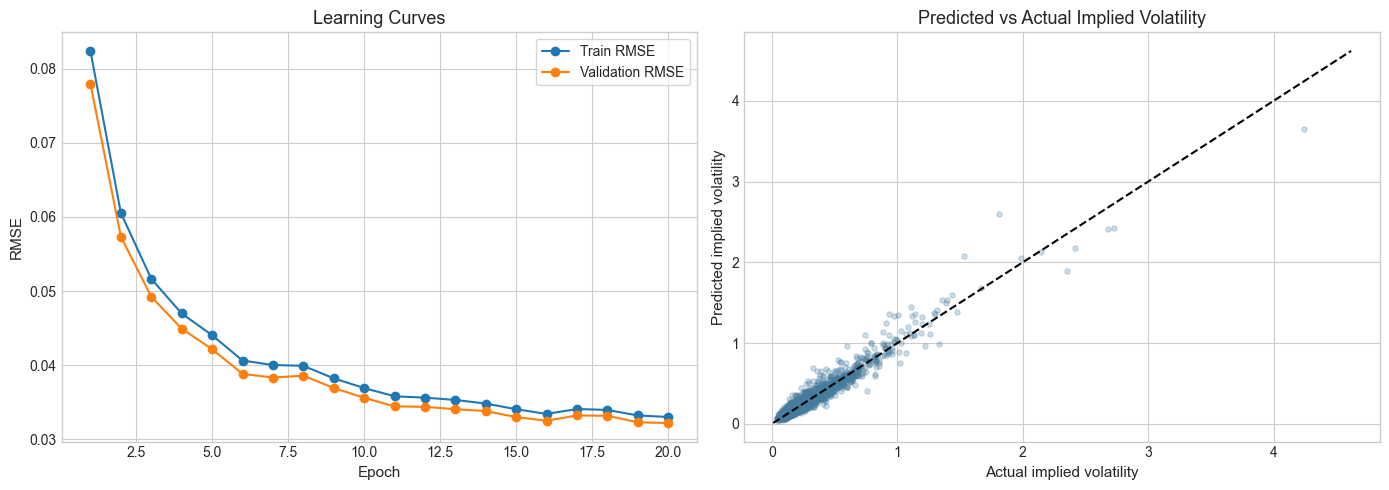


The retained neural network reaches a **test RMSE of 0.0314**, a
**test MAE of 0.0146**, and a **test R2 of 0.9300**.

The predicted-versus-actual scatter shows whether the model captures the main shape of the implied-volatility surface while keeping dispersion around the 45-degree line limited.


In [62]:
metrics_table = pd.DataFrame(
    [
        {"subset": "Train", **compute_regression_metrics(y_train, train_predictions)},
        {"subset": "Validation", **compute_regression_metrics(y_valid, valid_predictions)},
        {"subset": "Test", **compute_regression_metrics(y_test, test_predictions)},
    ]
).set_index("subset")
display(metrics_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_rmse"], marker="o", label="Train RMSE")
axes[0].plot(
    history_df["epoch"],
    history_df["validation_rmse"],
    marker="o",
    label="Validation RMSE",
)
axes[0].set_title("Learning Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("RMSE")
axes[0].legend()

scatter_sample = min(15000, len(y_test))
scatter_idx = rng.choice(len(y_test), size=scatter_sample, replace=False)
axes[1].scatter(
    y_test[scatter_idx],
    test_predictions[scatter_idx],
    alpha=0.25,
    s=14,
    color="#457b9d",
)
diagonal_lower = min(y_test.min(), test_predictions.min())
diagonal_upper = max(y_test.max(), test_predictions.max())
axes[1].plot(
    [diagonal_lower, diagonal_upper],
    [diagonal_lower, diagonal_upper],
    linestyle="--",
    color="black",
)
axes[1].set_title("Predicted vs Actual Implied Volatility")
axes[1].set_xlabel("Actual implied volatility")
axes[1].set_ylabel("Predicted implied volatility")

plt.tight_layout()
plt.show()

model_summary = f'''
The retained neural network reaches a **test RMSE of {metrics_table.loc['Test', 'RMSE']:.4f}**, a
**test MAE of {metrics_table.loc['Test', 'MAE']:.4f}**, and a **test R2 of {metrics_table.loc['Test', 'R2']:.4f}**.

The predicted-versus-actual scatter shows whether the model captures the main shape of the implied-volatility surface while keeping dispersion around the 45-degree line limited.
'''
display(Markdown(model_summary))

## 5. Model Explainability

The dedicated `shap` package is not available in the kernel, so the notebook computes SHAP-consistent Monte Carlo Shapley values directly from the fitted model. The approximation is performed on a representative test subsample and uses a training-background sample to estimate the expected prediction baseline.

,mean_abs_shap
TradePriceOption,0.113807
StrikePrice,0.107009
TimeToExpiration,0.098465
UnderlyingPrice,0.086106
option_type,0.060926
Rate,0.024705
TradeType,0.004393


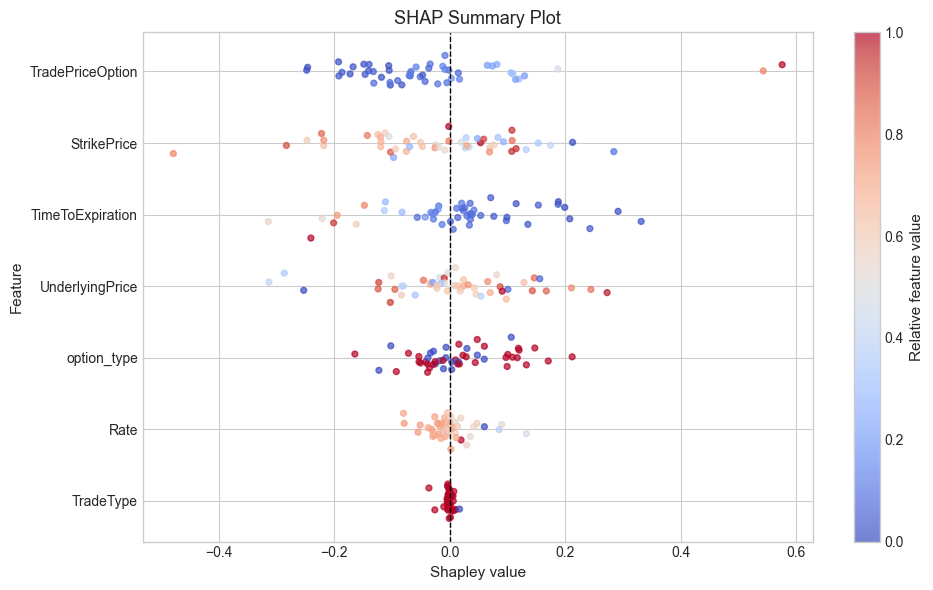

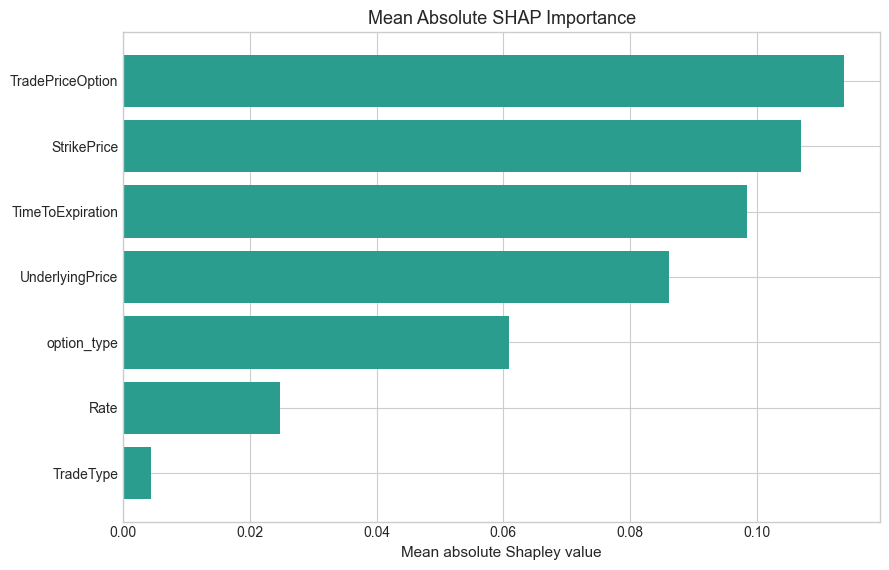

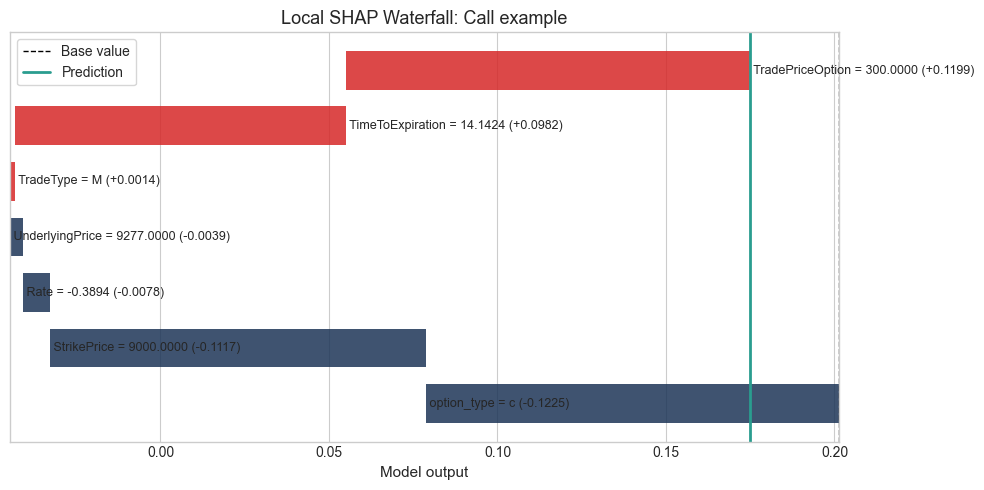

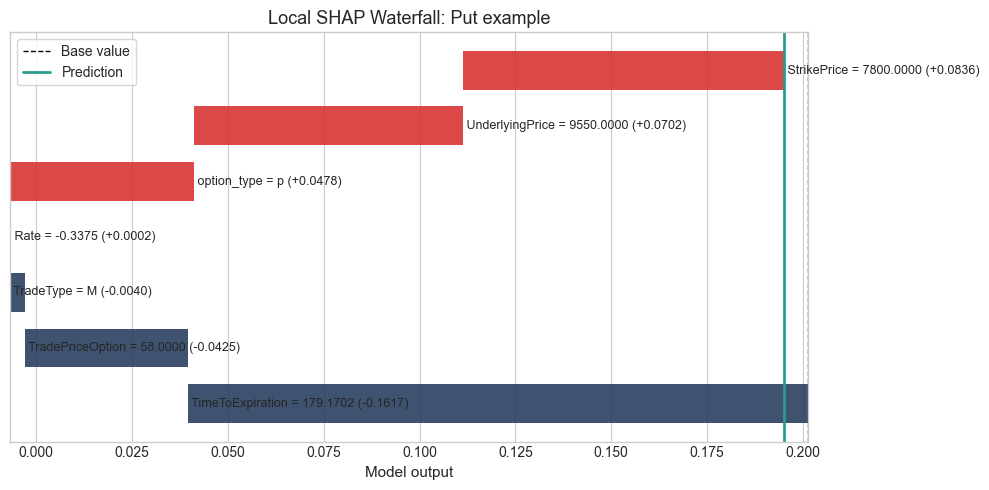


The SHAP ranking indicates that the most influential inputs are ['TradePriceOption', 'StrikePrice', 'TimeToExpiration', 'UnderlyingPrice', 'option_type'].

This ordering is economically plausible: strike, moneyness, rates, the underlying level, and maturity-related variables are central state variables for an implied-volatility surface.

The local waterfall plots show how these contributions add up from the background expectation to an individual prediction.


In [63]:
def predict_from_feature_frame(feature_frame: pd.DataFrame) -> np.ndarray:
    aligned_frame = feature_frame[FEATURE_COLUMNS].copy()
    return trained_model.predict(preprocessor.transform(aligned_frame))


def encode_feature_for_color(series: pd.Series) -> np.ndarray:
    if pd.api.types.is_numeric_dtype(series):
        values = series.astype(float).to_numpy()
    else:
        values = series.astype("category").cat.codes.to_numpy(dtype=float)

    if np.nanmax(values) == np.nanmin(values):
        return np.zeros_like(values, dtype=float)

    return (values - np.nanmin(values)) / (np.nanmax(values) - np.nanmin(values))


def feature_value_to_text(value) -> str:
    if isinstance(value, (float, np.floating)):
        return f"{value:.4f}"
    return str(value)


def approximate_shap_values(
    explain_frame: pd.DataFrame,
    background_frame: pd.DataFrame,
    feature_columns: list[str],
    n_permutations: int = 20,
    seed: int = 42,
) -> tuple[np.ndarray, float]:
    local_rng = np.random.default_rng(seed)
    explain_frame = explain_frame[feature_columns].reset_index(drop=True)
    background_frame = background_frame[feature_columns].reset_index(drop=True)

    n_features = len(feature_columns)
    shap_values = np.zeros((len(explain_frame), n_features), dtype=float)

    for row_idx in range(len(explain_frame)):
        explained_row = explain_frame.iloc[row_idx]
        contribution_sums = np.zeros(n_features, dtype=float)

        without_rows = []
        with_rows = []
        feature_index_log = []

        for _ in range(n_permutations):
            background_row = background_frame.iloc[local_rng.integers(len(background_frame))]
            permutation = local_rng.permutation(n_features)
            coalition_row = background_row.copy()

            for feature_idx in permutation:
                without_rows.append(coalition_row.copy())
                updated_row = coalition_row.copy()
                updated_row.iloc[feature_idx] = explained_row.iloc[feature_idx]
                with_rows.append(updated_row)
                feature_index_log.append(feature_idx)
                coalition_row = updated_row

        without_predictions = predict_from_feature_frame(pd.DataFrame(without_rows))
        with_predictions = predict_from_feature_frame(pd.DataFrame(with_rows))
        marginal_contributions = with_predictions - without_predictions

        for feature_idx, delta in zip(feature_index_log, marginal_contributions):
            contribution_sums[feature_idx] += delta

        shap_values[row_idx] = contribution_sums / n_permutations

    base_value = float(predict_from_feature_frame(background_frame).mean())
    reconstructed_predictions = base_value + shap_values.sum(axis=1)
    residual = predict_from_feature_frame(explain_frame) - reconstructed_predictions
    shap_values = shap_values + residual[:, None] / n_features

    return shap_values, base_value


def plot_shap_summary(
    shap_value_matrix: np.ndarray,
    feature_frame: pd.DataFrame,
    feature_importance: pd.Series,
    top_n: int = 12,
):
    top_features = feature_importance.head(top_n).index.tolist()[::-1]
    fig, ax = plt.subplots(figsize=(10, max(6, 0.45 * len(top_features) + 1)))

    for feature_rank, feature_name in enumerate(top_features):
        feature_position = FEATURE_COLUMNS.index(feature_name)
        shap_values = shap_value_matrix[:, feature_position]
        color_values = encode_feature_for_color(feature_frame[feature_name])
        y_jitter = feature_rank + rng.normal(0, 0.10, size=len(shap_values))

        scatter = ax.scatter(
            shap_values,
            y_jitter,
            c=color_values,
            cmap="coolwarm",
            alpha=0.70,
            s=18,
        )

    ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features)
    ax.set_title("SHAP Summary Plot")
    ax.set_xlabel("Shapley value")
    ax.set_ylabel("Feature")
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Relative feature value")
    plt.tight_layout()
    plt.show()


def plot_shap_bar(feature_importance: pd.Series, top_n: int = 12):
    top_importance = feature_importance.head(top_n).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, max(5, 0.4 * top_n + 1)))
    ax.barh(top_importance.index, top_importance.values, color="#2a9d8f")
    ax.set_title("Mean Absolute SHAP Importance")
    ax.set_xlabel("Mean absolute Shapley value")
    plt.tight_layout()
    plt.show()


def plot_waterfall_explanation(
    base_value: float,
    shap_row: pd.Series,
    feature_row: pd.Series,
    prediction: float,
    title: str,
    top_n: int = 10,
):
    ordered_features = shap_row.abs().sort_values(ascending=False)
    top_features = ordered_features.head(top_n).index.tolist()

    remaining_contribution = shap_row.drop(top_features).sum()
    display_contributions = shap_row[top_features].copy()
    if abs(remaining_contribution) > 1e-12:
        display_contributions.loc["Other features"] = remaining_contribution

    display_contributions = display_contributions.sort_values()
    running_value = base_value

    fig, ax = plt.subplots(figsize=(10, max(5, 0.45 * len(display_contributions) + 1)))

    for row_number, (feature_name, contribution) in enumerate(display_contributions.items()):
        start = running_value
        end = running_value + contribution
        color = "#d62828" if contribution >= 0 else "#1d3557"
        ax.barh(
            y=row_number,
            width=contribution,
            left=start,
            height=0.7,
            color=color,
            alpha=0.85,
        )

        if feature_name == "Other features":
            label = f"{feature_name}: {contribution:+.4f}"
        else:
            label = (
                f"{feature_name} = {feature_value_to_text(feature_row[feature_name])}"
                f" ({contribution:+.4f})"
            )
        ax.text(
            x=end,
            y=row_number,
            s=f" {label}",
            va="center",
            ha="left",
            fontsize=9,
        )
        running_value = end

    ax.axvline(base_value, color="black", linestyle="--", linewidth=1, label="Base value")
    ax.axvline(prediction, color="#2a9d8f", linestyle="-", linewidth=2, label="Prediction")
    ax.set_yticks([])
    ax.set_xlabel("Model output")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


explain_size = min(EXPLAINABILITY_SAMPLE_SIZE, len(X_test_raw))
background_size = min(BACKGROUND_SAMPLE_SIZE, len(X_train_raw))

explain_frame = X_test_raw.sample(n=explain_size, random_state=RANDOM_STATE)
background_frame = X_train_raw.sample(n=background_size, random_state=RANDOM_STATE)
explain_predictions = pd.Series(
    predict_from_feature_frame(explain_frame),
    index=explain_frame.index,
)

shap_value_matrix, shap_base_value = approximate_shap_values(
    explain_frame=explain_frame,
    background_frame=background_frame,
    feature_columns=FEATURE_COLUMNS,
    n_permutations=SHAP_PERMUTATIONS,
    seed=RANDOM_STATE,
)

shap_values_df = pd.DataFrame(
    shap_value_matrix,
    index=explain_frame.index,
    columns=FEATURE_COLUMNS,
)
mean_abs_shap = shap_values_df.abs().mean().sort_values(ascending=False)

display(mean_abs_shap.rename("mean_abs_shap").to_frame())
plot_shap_summary(shap_value_matrix, explain_frame, mean_abs_shap, top_n=12)
plot_shap_bar(mean_abs_shap, top_n=12)

example_indices = []
option_type_feature = "option_type"
if option_type_feature in explain_frame.columns:
    call_candidates = explain_frame.index[
        explain_frame[option_type_feature].map(normalize_option_type) == "call"
    ]
    put_candidates = explain_frame.index[
        explain_frame[option_type_feature].map(normalize_option_type) == "put"
    ]
    if len(call_candidates) > 0:
        example_indices.append(call_candidates[0])
    if len(put_candidates) > 0:
        example_indices.append(put_candidates[0])

if len(example_indices) < 2:
    example_indices = explain_frame.index[:2].tolist()

for example_idx in example_indices[:2]:
    example_shap_row = shap_values_df.loc[example_idx]
    example_feature_row = explain_frame.loc[example_idx]
    example_prediction = explain_predictions.loc[example_idx]
    option_label = ""
    if option_type_feature in explain_frame.columns:
        option_label = normalize_option_type(example_feature_row[option_type_feature]).capitalize() + " example"
    else:
        option_label = f"Observation {example_idx}"
    plot_waterfall_explanation(
        base_value=shap_base_value,
        shap_row=example_shap_row,
        feature_row=example_feature_row,
        prediction=float(example_prediction),
        title=f"Local SHAP Waterfall: {option_label}",
        top_n=10,
    )

shap_summary_markdown = f'''
The SHAP ranking indicates that the most influential inputs are {mean_abs_shap.head(5).index.tolist()}.

This ordering is economically plausible: strike, moneyness, rates, the underlying level, and maturity-related variables are central state variables for an implied-volatility surface.

The local waterfall plots show how these contributions add up from the background expectation to an individual prediction.
'''
display(Markdown(shap_summary_markdown))

## 6. Prediction Sensitivity Analysis

The next step studies how the fitted neural network reacts when economically important inputs move around a realistic base scenario. The base scenario is chosen from the test set as a representative contract close to the median state of the market.

In [64]:
from src.enums.data_enums import VolatilityDBEnum

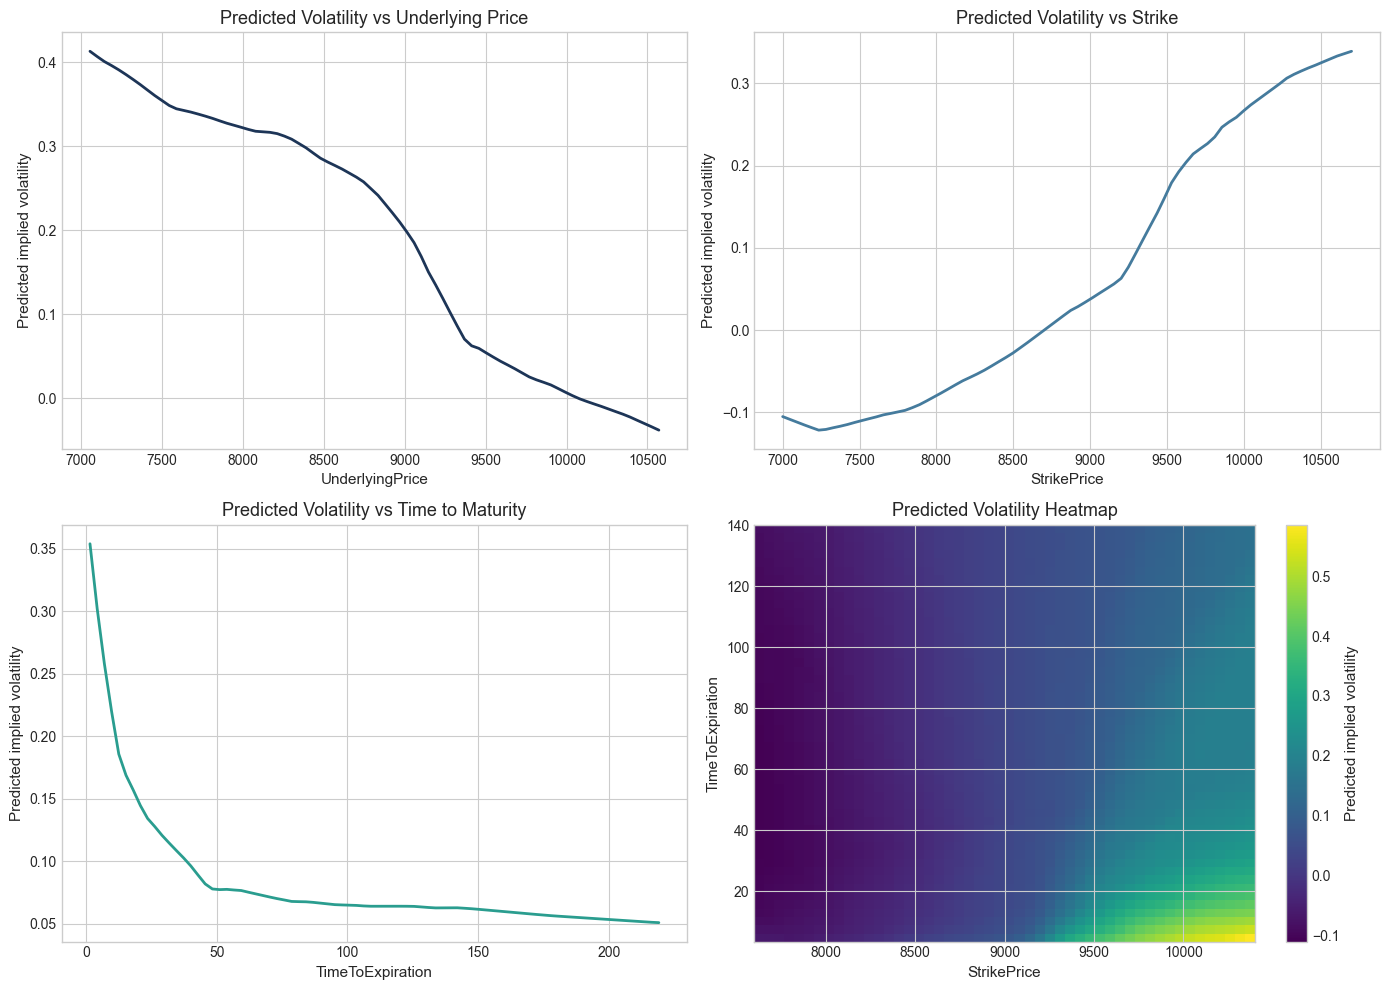


These curves describe the local shape learned by the neural network around a representative test observation.

The plots are especially useful because they convert a high-dimensional regression model into a set of one-factor stress tests: how the fitted implied volatility changes when the underlying, strike, or maturity is perturbed while the rest of the state is held fixed.


In [65]:
def refresh_scenario_columns(
    raw_frame: pd.DataFrame, varied_column: str | None = None
) -> pd.DataFrame:
    refreshed = raw_frame.copy()

    if {"t_in_years", "TimeToExpiration"}.issubset(refreshed.columns):
        if varied_column == "t_in_years":
            refreshed["TimeToExpiration"] = refreshed["t_in_years"] * 365.0
        elif varied_column == "TimeToExpiration":
            refreshed["t_in_years"] = refreshed["TimeToExpiration"] / 365.0

    if {"r_in_decimals", "Rate"}.issubset(refreshed.columns):
        if varied_column == "r_in_decimals":
            refreshed["Rate"] = refreshed["r_in_decimals"] * 100.0
        elif varied_column == "Rate":
            refreshed["r_in_decimals"] = refreshed["Rate"] / 100.0

    return refreshed


def select_representative_row(
    raw_frame: pd.DataFrame, option_kind: str | None = None
) -> pd.Series:
    candidate_frame = raw_frame.copy()

    if option_kind is not None and "option_type" in candidate_frame.columns:
        normalized_types = candidate_frame["option_type"].map(normalize_option_type)
        candidate_frame = candidate_frame.loc[normalized_types == option_kind].copy()

    anchor_columns = [
        column
        for column in [
            VolatilityDBEnum.UNDERLYING_PRICE,
            VolatilityDBEnum.STRIKE_PRICE,
            VolatilityDBEnum.TIME_TO_EXPIRATION,
            VolatilityDBEnum.RATE,
        ]
        if column is not None and column.value in candidate_frame.columns
    ]
    anchor = candidate_frame[anchor_columns].median(numeric_only=True)
    distance = (candidate_frame[anchor_columns] - anchor).pow(2).sum(axis=1)
    return candidate_frame.loc[distance.idxmin()].copy()


def volatility_curve_from_scenario(
    base_row: pd.Series,
    varied_column: str,
    grid: np.ndarray,
) -> np.ndarray:
    scenario_frame = pd.DataFrame([base_row.to_dict()] * len(grid))
    scenario_frame[varied_column] = grid
    scenario_frame = refresh_scenario_columns(
        scenario_frame, varied_column=varied_column
    )
    return trained_model.predict(preprocessor.transform(scenario_frame))


sensitivity_base_row = select_representative_row(test_reference_df, option_kind="call")

spot_column = VolatilityDBEnum.UNDERLYING_PRICE
strike_column = VolatilityDBEnum.STRIKE_PRICE
time_column = VolatilityDBEnum.TIME_TO_EXPIRATION

spot_grid = np.linspace(
    test_reference_df[spot_column].quantile(0.05),
    test_reference_df[spot_column].quantile(0.95),
    80,
)
strike_grid = np.linspace(
    test_reference_df[strike_column].quantile(0.05),
    test_reference_df[strike_column].quantile(0.95),
    80,
)
time_grid = np.linspace(
    max(test_reference_df[time_column].quantile(0.05), 1e-6),
    test_reference_df[time_column].quantile(0.95),
    80,
)

vol_vs_spot = volatility_curve_from_scenario(
    sensitivity_base_row, spot_column, spot_grid
)
vol_vs_strike = volatility_curve_from_scenario(
    sensitivity_base_row, strike_column, strike_grid
)
vol_vs_time = volatility_curve_from_scenario(
    sensitivity_base_row, time_column, time_grid
)

heatmap_strike = np.linspace(
    test_reference_df[strike_column].quantile(0.10),
    test_reference_df[strike_column].quantile(0.90),
    50,
)
heatmap_time = np.linspace(
    max(test_reference_df[time_column].quantile(0.10), 1e-6),
    test_reference_df[time_column].quantile(0.90),
    50,
)
strike_mesh, time_mesh = np.meshgrid(heatmap_strike, heatmap_time)
heatmap_frame = pd.DataFrame([sensitivity_base_row.to_dict()] * strike_mesh.size)
heatmap_frame[strike_column] = strike_mesh.ravel()
heatmap_frame[time_column] = time_mesh.ravel()
heatmap_frame = refresh_scenario_columns(heatmap_frame, varied_column=time_column)
heatmap_vol =  trained_model.predict(preprocessor.transform(heatmap_frame)).reshape(strike_mesh.shape)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(spot_grid, vol_vs_spot, color="#1d3557", linewidth=2)
axes[0, 0].set_title("Predicted Volatility vs Underlying Price")
axes[0, 0].set_xlabel(spot_column)
axes[0, 0].set_ylabel("Predicted implied volatility")

axes[0, 1].plot(strike_grid, vol_vs_strike, color="#457b9d", linewidth=2)
axes[0, 1].set_title("Predicted Volatility vs Strike")
axes[0, 1].set_xlabel(strike_column)
axes[0, 1].set_ylabel("Predicted implied volatility")

axes[1, 0].plot(time_grid, vol_vs_time, color="#2a9d8f", linewidth=2)
axes[1, 0].set_title("Predicted Volatility vs Time to Maturity")
axes[1, 0].set_xlabel(time_column)
axes[1, 0].set_ylabel("Predicted implied volatility")

image = axes[1, 1].imshow(
    heatmap_vol,
    aspect="auto",
    origin="lower",
    extent=[
        heatmap_strike.min(),
        heatmap_strike.max(),
        heatmap_time.min(),
        heatmap_time.max(),
    ],
    cmap="viridis",
)
axes[1, 1].set_title("Predicted Volatility Heatmap")
axes[1, 1].set_xlabel(strike_column)
axes[1, 1].set_ylabel(time_column)
plt.colorbar(image, ax=axes[1, 1], label="Predicted implied volatility")

plt.tight_layout()
plt.show()

sensitivity_markdown = f"""
These curves describe the local shape learned by the neural network around a representative test observation.

The plots are especially useful because they convert a high-dimensional regression model into a set of one-factor stress tests: how the fitted implied volatility changes when the underlying, strike, or maturity is perturbed while the rest of the state is held fixed.
"""
display(Markdown(sensitivity_markdown))

## 7. Black-Scholes Pricing Using Predicted Volatility

The predicted volatility is now fed into a Black-Scholes pricing function. Column detection is based on name similarity so that the notebook does not assume a fixed schema beyond the target column.

In [70]:
PREFERRED_PRICING_COLUMNS = {
    "spot": ["UnderlyingPrice"],
    "strike": ["StrikePrice"],
    "time": ["t_in_years", "TimeToExpiration"],
    "rate": ["r_in_decimals", "Rate"],
    "option_type": ["option_type"],
    "market_price": ["TradePriceOption"],
    "dividend_yield": [],
}


def coerce_time_to_years(values: np.ndarray, source_column: str, assumptions: list[str]) -> np.ndarray:
    coerced_values = np.asarray(values, dtype=float)
    if np.nanmedian(coerced_values) > 5.0:
        coerced_values = coerced_values / 365.0
        assumptions.append(
            f"`{source_column}` appears to be measured in days, so it was divided by 365 to obtain years."
        )
    return coerced_values


def coerce_rate_to_decimals(values: np.ndarray, source_column: str, assumptions: list[str]) -> np.ndarray:
    coerced_values = np.asarray(values, dtype=float)
    if np.nanmedian(np.abs(coerced_values)) > 1.0:
        coerced_values = coerced_values / 100.0
        assumptions.append(
            f"`{source_column}` appears to be quoted in percent units, so it was divided by 100."
        )
    return coerced_values


def black_scholes_price(S, K, T, r, sigma, option_type, q=0.0):
    S = np.asarray(S, dtype=float)
    K = np.asarray(K, dtype=float)
    T = np.clip(np.asarray(T, dtype=float), 1e-8, None)
    r = np.asarray(r, dtype=float)
    sigma = np.clip(np.asarray(sigma, dtype=float), 1e-8, None)
    q = np.asarray(q, dtype=float)

    option_array = np.asarray(option_type, dtype=object)
    option_array = np.array([normalize_option_type(value) for value in option_array], dtype=object)

    d1 = (
        np.log(np.clip(S, 1e-8, None) / np.clip(K, 1e-8, None))
        + (r - q + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = np.exp(-q * T) * S * norm.cdf(d1) - np.exp(-r * T) * K * norm.cdf(d2)
    put_price = np.exp(-r * T) * K * norm.cdf(-d2) - np.exp(-q * T) * S * norm.cdf(-d1)

    return np.where(option_array == "c", call_price, put_price)


def extract_pricing_inputs(raw_frame: pd.DataFrame) -> tuple[dict, list[str]]:
    assumptions = []

    time_values = coerce_time_to_years(
        raw_frame[VolatilityDBEnum.TIME_TO_EXPIRATION].to_numpy(),
        VolatilityDBEnum.TIME_TO_EXPIRATION,
        assumptions,
    )

    rate_values = coerce_rate_to_decimals(
            raw_frame[VolatilityDBEnum.RATE].to_numpy(),
            VolatilityDBEnum.RATE,
            assumptions,
        )
    
    option_values = raw_frame["option_type"].map(normalize_option_type).to_numpy()

    dividend_values = np.zeros(len(raw_frame), dtype=float)
    assumptions.append("No dividend-yield column was detected, so q = 0 was assumed.")

    pricing_inputs = {
        "S": raw_frame[VolatilityDBEnum.UNDERLYING_PRICE].to_numpy(dtype=float),
        "K": raw_frame[VolatilityDBEnum.STRIKE_PRICE].to_numpy(dtype=float),
        "T": time_values,
        "r": rate_values,
        "option_type": option_values,
        "q": dividend_values,
    }
    return pricing_inputs, assumptions


test_pricing_df = test_reference_df.copy()
test_pricing_df["PredictedImpliedVolatility"] = trained_model.predict(preprocessor.transform(test_pricing_df))

pricing_inputs, pricing_assumptions = extract_pricing_inputs(test_pricing_df)
test_pricing_df["BlackScholesPriceFromPredictedVol"] = black_scholes_price(
    S=pricing_inputs["S"],
    K=pricing_inputs["K"],
    T=pricing_inputs["T"],
    r=pricing_inputs["r"],
    sigma=test_pricing_df["PredictedImpliedVolatility"].to_numpy(),
    option_type=pricing_inputs["option_type"],
    q=pricing_inputs["q"],
)

assumptions_text = (
    "\n".join([f"- {assumption}" for assumption in pricing_assumptions])
    if pricing_assumptions
    else "- No extra pricing assumptions were required."
)
display(Markdown(f"**Pricing assumptions**\n\n{assumptions_text}"))
test_pricing_df.head()

**Pricing assumptions**

- `TimeToExpiration` appears to be measured in days, so it was divided by 365 to obtain years.
- No dividend-yield column was detected, so q = 0 was assumed.

,OptionContractCode,FutureContractCode,UnderlyingPrice,SessionDate,MarketCode,TradeExecID,TradePriceOption,Quantity,TradeType,StrikePrice,...,ExecDatetime,TimeToExpiration,UnderlyingExecDatetime,Rate,t_in_years,r_in_decimals,option_type,ImpliedVolatility,PredictedImpliedVolatility,BlackScholesPriceFromPredictedVol
347442,CIBX 9200K21,FIBXK1,9119.0,2021-05-14,M3,100059833,42.0,5,M,9200.0,...,2021-05-14 17:04:07.047134,7.163807,2021-05-14 17:04:03.853744,-0.626206,0.019626869383117706,-0.006262059043384396,c,0.147878,0.139113,207.479390
340429,CIBX 8700J21,FIBXJ1,8390.0,2021-03-23,M3,100049620,32.0,5,M,8700.0,...,2021-03-23 12:40:27.094052,24.346909,2021-03-23 12:40:25.485333,-0.571459,0.06670385927029426,-0.005714591197963081,c,0.151611,0.155142,652.343754
22337,PIBX 9900J17,FIBXJ7,10233.0,2017-03-23,M3,OM0001671632,69.0,1,M,9900.0,...,2017-03-23 13:01:45.000000,29.332119,2017-03-23 13:01:06.000000,-0.360217,0.08036196727549468,-0.0036021689353352747,p,0.167866,0.169056,174.834613
312311,PIBX 5800Z20,FIBXZ0,6900.0,2020-09-01,M3,100010921,102.0,1,M,5800.0,...,2020-09-01 12:34:03.734197,108.351349,2020-08-03 18:40:29.859196,-0.514739,0.29685300183292107,-0.0051473941135450904,p,0.331181,0.311219,393.643689
323598,CIBX 8000X20,FIBXX0,7922.0,2020-11-17,M3,100026265,40.0,1,M,8000.0,...,2020-11-17 11:01:07.292912,3.415888,2020-11-17 11:01:03.577959,-0.650734,0.009358596749365806,-0.006507340293885417,c,0.235692,0.233030,152.380354


## 8. Option Price Sensitivity

The pricing perspective makes the volatility model economically interpretable. The plots below propagate the neural-network volatility forecasts into Black-Scholes prices for representative call and put scenarios.

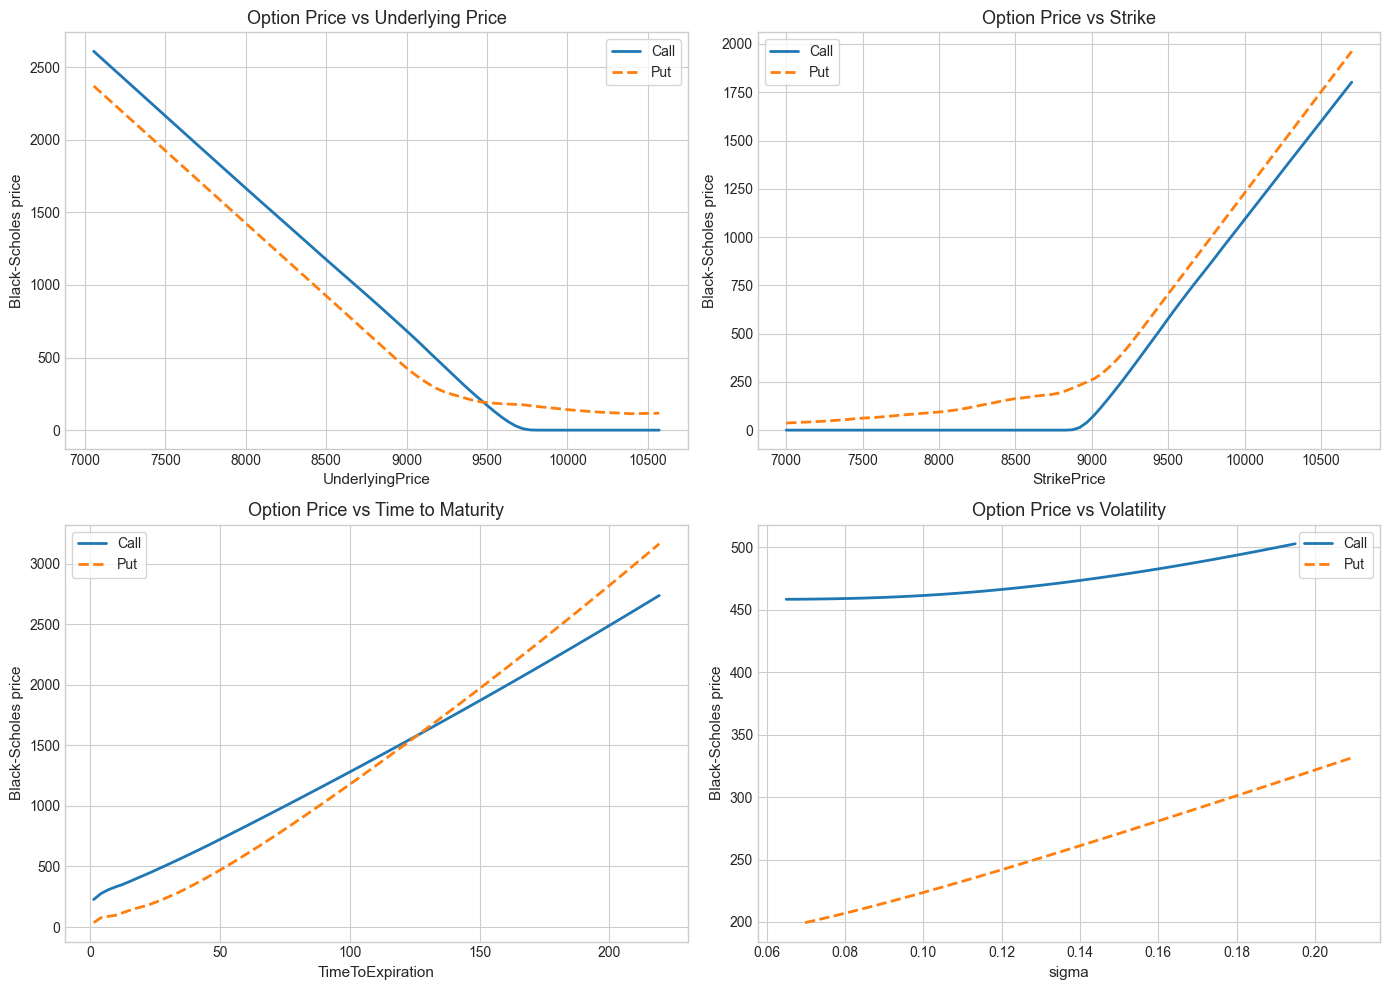


These pricing curves translate the learned volatility response into economic terms.

The expected directions should hold locally:

- call prices should tend to increase with the underlying level and volatility, and decrease with higher strikes;
- put prices should benefit from higher strikes and lower underlying levels;
- both calls and puts should gain value as predicted volatility increases.


In [76]:
def price_curve_from_scenario(
    base_row: pd.Series,
    varied_column: str,
    grid: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    scenario_frame = pd.DataFrame([base_row.to_dict()] * len(grid))
    scenario_frame[varied_column] = grid
    scenario_frame = refresh_scenario_columns(scenario_frame, varied_column=varied_column)

    predicted_sigma = np.clip(trained_model.predict(preprocessor.transform(scenario_frame)), 1e-6, None)
    pricing_inputs_local, _ = extract_pricing_inputs(scenario_frame)
    option_prices = black_scholes_price(
        S=pricing_inputs_local["S"],
        K=pricing_inputs_local["K"],
        T=pricing_inputs_local["T"],
        r=pricing_inputs_local["r"],
        sigma=predicted_sigma,
        option_type=pricing_inputs_local["option_type"],
        q=pricing_inputs_local["q"],
    )
    return predicted_sigma, option_prices


available_option_kinds = ["call"]
option_type_column = "option_type"
if option_type_column is not None and option_type_column in test_pricing_df.columns:
    available_option_kinds = (
        test_pricing_df[option_type_column].map(normalize_option_type).dropna().unique().tolist()
    )
    available_option_kinds = sorted(available_option_kinds)

scenario_rows = {
    option_kind: select_representative_row(test_pricing_df, option_kind=option_kind)
    for option_kind in available_option_kinds[:2]
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
line_styles = {"call": "-", "put": "--"}

for option_kind, base_row in scenario_rows.items():
    _, price_vs_spot = price_curve_from_scenario(base_row, spot_column, spot_grid)
    _, price_vs_strike = price_curve_from_scenario(base_row, strike_column, strike_grid)
    _, price_vs_time = price_curve_from_scenario(base_row, time_column, time_grid)

    base_sigma = float(np.clip(trained_model.predict(preprocessor.transform(pd.DataFrame([base_row.to_dict()])))[0], 1e-6, None))
    sigma_grid = np.linspace(max(0.05, base_sigma * 0.50), base_sigma * 1.50, 80)
    pricing_inputs_single, _ = extract_pricing_inputs(pd.DataFrame([base_row.to_dict()] * len(sigma_grid)))
    price_vs_sigma = black_scholes_price(
        S=pricing_inputs_single["S"],
        K=pricing_inputs_single["K"],
        T=pricing_inputs_single["T"],
        r=pricing_inputs_single["r"],
        sigma=sigma_grid,
        option_type=np.full(len(sigma_grid), option_kind, dtype=object),
        q=pricing_inputs_single["q"],
    )

    style = line_styles.get(option_kind, "-")
    label = option_kind.capitalize()
    axes[0, 0].plot(spot_grid, price_vs_spot, linestyle=style, linewidth=2, label=label)
    axes[0, 1].plot(strike_grid, price_vs_strike, linestyle=style, linewidth=2, label=label)
    axes[1, 0].plot(time_grid, price_vs_time, linestyle=style, linewidth=2, label=label)
    axes[1, 1].plot(sigma_grid, price_vs_sigma, linestyle=style, linewidth=2, label=label)

axes[0, 0].set_title("Option Price vs Underlying Price")
axes[0, 0].set_xlabel(spot_column)
axes[0, 0].set_ylabel("Black-Scholes price")

axes[0, 1].set_title("Option Price vs Strike")
axes[0, 1].set_xlabel(strike_column)
axes[0, 1].set_ylabel("Black-Scholes price")

axes[1, 0].set_title("Option Price vs Time to Maturity")
axes[1, 0].set_xlabel(time_column)
axes[1, 0].set_ylabel("Black-Scholes price")

axes[1, 1].set_title("Option Price vs Volatility")
axes[1, 1].set_xlabel("sigma")
axes[1, 1].set_ylabel("Black-Scholes price")

for ax in axes.ravel():
    ax.legend()

plt.tight_layout()
plt.show()

pricing_sensitivity_summary = '''
These pricing curves translate the learned volatility response into economic terms.

The expected directions should hold locally:

- call prices should tend to increase with the underlying level and volatility, and decrease with higher strikes;
- put prices should benefit from higher strikes and lower underlying levels;
- both calls and puts should gain value as predicted volatility increases.
'''
display(Markdown(pricing_sensitivity_summary))

## 9. Optional Market Price Comparison

If an observed option market-price column exists, the notebook compares it with the Black-Scholes price obtained by plugging the predicted volatility into the pricing formula.

,value
RMSE,978.837257
MAE,509.491228
R2,-20.689554


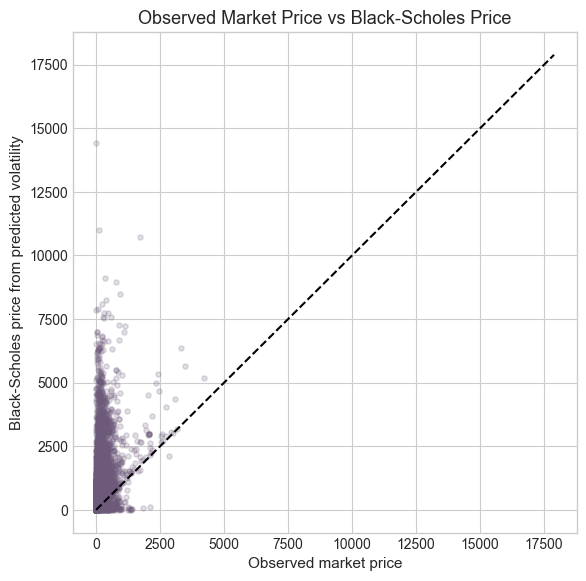

In [78]:
price_comparison_metrics = None

market_price_column = VolatilityDBEnum.TRADE_PRICE_OPTION
price_comparison_metrics = pd.Series(
    compute_regression_metrics(
        test_pricing_df[market_price_column].to_numpy(),
        test_pricing_df["BlackScholesPriceFromPredictedVol"].to_numpy(),
    )
)
display(price_comparison_metrics.rename("value").to_frame())

price_scatter_size = min(12000, len(test_pricing_df))
price_scatter_idx = rng.choice(len(test_pricing_df), size=price_scatter_size, replace=False)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(
    test_pricing_df.iloc[price_scatter_idx][market_price_column],
    test_pricing_df.iloc[price_scatter_idx]["BlackScholesPriceFromPredictedVol"],
    alpha=0.20,
    s=14,
    color="#6d597a",
)
lower_bound = min(
    test_pricing_df[market_price_column].min(),
    test_pricing_df["BlackScholesPriceFromPredictedVol"].min(),
)
upper_bound = max(
    test_pricing_df[market_price_column].max(),
    test_pricing_df["BlackScholesPriceFromPredictedVol"].max(),
)
ax.plot([lower_bound, upper_bound], [lower_bound, upper_bound], linestyle="--", color="black")
ax.set_title("Observed Market Price vs Black-Scholes Price")
ax.set_xlabel("Observed market price")
ax.set_ylabel("Black-Scholes price from predicted volatility")
plt.show()

## 10. Conclusions

The final cell collects the main quantitative conclusions from the prediction, explainability, and pricing exercises.

In [80]:
top_feature_names = mean_abs_shap.head(5).index.tolist()
price_comparison_sentence = (
    f"When the predicted volatility is propagated through Black-Scholes, the resulting option prices reach "
    f"an RMSE of **{price_comparison_metrics['RMSE']:.4f}**, an MAE of **{price_comparison_metrics['MAE']:.4f}**, "
    f"and an R2 of **{price_comparison_metrics['R2']:.4f}** against the observed market prices."
    if price_comparison_metrics is not None
    else "A direct market-price comparison was not available because no market-price column was detected."
)

conclusions_markdown = f'''
## Conclusions

- The neural network reaches a **test RMSE of {metrics_table.loc['Test', 'RMSE']:.4f}**, a
  **test MAE of {metrics_table.loc['Test', 'MAE']:.4f}**, and a **test R2 of {metrics_table.loc['Test', 'R2']:.4f}**
  for `{TARGET_COLUMN}`.
- According to the SHAP analysis, the dominant drivers are {top_feature_names}.
- The sensitivity plots show how the predicted volatility surface reacts locally to changes in the underlying,
  strike, and time to maturity around realistic contracts from the test set.
- The Black-Scholes section translates these volatility changes into option-price effects, which is useful for
  linking machine-learning outputs to a familiar financial interpretation.
- {price_comparison_sentence}
- Main limitations: the notebook uses a scikit-learn neural network because TensorFlow and PyTorch are not
  available in the current kernel; SHAP values are Monte Carlo approximations because the dedicated `shap`
  package is unavailable; Black-Scholes is used as a pricing proxy even though the underlying is futures-linked;
  and the random split should be complemented by a stricter time-based backtest in future work.
- Natural extensions include hyperparameter tuning, Black-76 pricing, monotonicity-aware modelling, and richer
  market-regime features.
'''
display(Markdown(conclusions_markdown))


## Conclusions

- The neural network reaches a **test RMSE of 0.0314**, a
  **test MAE of 0.0146**, and a **test R2 of 0.9300**
  for `ImpliedVolatility`.
- According to the SHAP analysis, the dominant drivers are ['TradePriceOption', 'StrikePrice', 'TimeToExpiration', 'UnderlyingPrice', 'option_type'].
- The sensitivity plots show how the predicted volatility surface reacts locally to changes in the underlying,
  strike, and time to maturity around realistic contracts from the test set.
- The Black-Scholes section translates these volatility changes into option-price effects, which is useful for
  linking machine-learning outputs to a familiar financial interpretation.
- When the predicted volatility is propagated through Black-Scholes, the resulting option prices reach an RMSE of **978.8373**, an MAE of **509.4912**, and an R2 of **-20.6896** against the observed market prices.
- Main limitations: the notebook uses a scikit-learn neural network because TensorFlow and PyTorch are not
  available in the current kernel; SHAP values are Monte Carlo approximations because the dedicated `shap`
  package is unavailable; Black-Scholes is used as a pricing proxy even though the underlying is futures-linked;
  and the random split should be complemented by a stricter time-based backtest in future work.
- Natural extensions include hyperparameter tuning, Black-76 pricing, monotonicity-aware modelling, and richer
  market-regime features.
